# IT Support Dashboard - Supporting Notebook 3

This notebook documents the text normalisation stage for the English ticket subset. It starts from the English parquet import and evaluates whether lemmatisation improves thematic recurrence signals without materially distorting corpus structure.

## Text Normalisation and Thematic Recurrence Detection

Notebook 3 provides the text normalisation and recurrence analysis for the cleaned English subset. We apply Natural Language Processing (NLP) methods to quantify how frequently similar issues recur across tickets. Ticket text is represented using Term Frequency-Inverse Document Frequency (TF-IDF), and thematic overlap is measured with cosine similarity.

- Term Frequency (TF): how often a term appears within a ticket.
- Inverse Document Frequency (IDF): how rare that term is across the corpus.

Common terms across many tickets (for example, error, crash, security) receive lower weights, while informative, context-specific terms (for example, timeout, compatibility) receive higher weights. This representation supports a reproducible statistical comparison of nearest-neighbour similarity before and after lemmatisation.

### Importing

First, the required packages for this process were imported, the necessary folders were created using the config file, and the clean dataset was read.

In [1]:
# Importing essential packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, gaussian_kde
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Add project root to sys.path by searching upward for config.py
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists()), None
)
if project_root is None:
    raise FileNotFoundError("Could not locate project root containing config.py")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config

Config.ensure_directories()

# Reading the initial dataset as a DataFrame: df
df = pd.read_parquet(Config.ENGLISH_PARQUET_PATH, engine="pyarrow")

display(df)

[Config] Verified project directory structure under C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis


,Subject,Body,Answer,Type,Queue,Priority,Language,Version,Tag_1,Tag_2,Tag_3,Tag_4,Tag_5,Tag_6,Tag_7,Tag_8
0,Account Disruption,"Dear Customer Support Team, I am writing to re...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,High,EN,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team, I hope this messag...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,Medium,EN,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team, I hope this messag...",We appreciate you reaching out with your billi...,Request,Billing and Payments,Low,EN,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compa...,"Dear Support Team, I hope this message reaches...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,Medium,EN,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support, I hope this message rea...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,High,EN,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13724,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,We apologize for the billing discrepancy in th...,Incident,Billing and Payments,High,EN,400,Billing,Payment,Performance,Bug,NaN,NaN,NaN,NaN
13725,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...","Dear [Name], we acknowledge the urgency of the...",Problem,Product Support,Medium,EN,400,Security,Incident,Bug,Performance,NaN,NaN,NaN,NaN
13726,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,High,EN,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
13727,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,High,EN,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


### Boosting signal, reducing noise

First, we combined the subject, body, and answer fields into one large text to create a stronger signal of what the key issues the customer was experiencing.

In [ ]:
# Creating a lemmatising text dataframe
lemmatised_text_df = df[
    ["Subject", "Body", "Answer", "Type", "Queue", "Priority", "Language", "Version"]
].copy()

# Combining text to boost signal
lemmatised_text_df["Combined Text"] = (
    lemmatised_text_df["Subject"]
    + " "
    + lemmatised_text_df["Body"]
    + " "
    + lemmatised_text_df["Answer"]
)

# Drop redundant text columns
lemmatised_text_df.drop(
    columns=["Language", "Subject", "Body", "Answer"], axis=1, inplace=True
)

# Show lemmatised dataframe
display(lemmatised_text_df)

,Type,Queue,Priority,Version,Combined Text
0,Incident,Technical Support,High,51,"Account Disruption Dear Customer Support Team,..."
1,Request,Returns and Exchanges,Medium,51,Query About Smart Home System Integration Feat...
2,Request,Billing and Payments,Low,51,Inquiry Regarding Invoice Details Dear Custome...
3,Problem,Sales and Pre-Sales,Medium,51,Question About Marketing Agency Software Compa...
4,Request,Technical Support,High,51,"Feature Query Dear Customer Support, I hope th..."
...,...,...,...,...,...
13724,Incident,Billing and Payments,High,400,Problem with Billing Adjustment An unexpected ...
13725,Problem,Product Support,Medium,400,Urgent: Incident Involving Data Breach in Medi...
13726,Incident,Technical Support,High,400,Performance Problem with Data Analytics Tool T...
13727,Change,IT Support,High,400,Update Request for SaaS Platform Integration F...


The combined text was then normalised (lemmatised) to reduce redundant word forms, ensuring that morphologically similar words (e.g. running, ran, runs) were treated as one concept (run).

In [4]:
# Lemmatization using spaCy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


# Function to lemmatize text
def lemmatise_text(text: str) -> str:
    """Return lemmatized string of alphabetic, non-stopword tokens."""
    doc = nlp(text)
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_stop and token.is_alpha and len(token) > 2
    )


# Apply lemmatization to each record
print("Lemmatising the text (~3-5 mins)...")
lemmatised_text_df["Lemmatised Text"] = lemmatised_text_df["Combined Text"].apply(
    lemmatise_text
)

# Measure word-token reduction from lemmatisation
lemmatised_text_df["Tokens Before"] = (
    lemmatised_text_df["Combined Text"].str.split().str.len()
)
lemmatised_text_df["Tokens After"] = (
    lemmatised_text_df["Lemmatised Text"].str.split().str.len()
)

# Show changes at a glance
display(
    lemmatised_text_df[
        ["Combined Text", "Lemmatised Text", "Tokens Before", "Tokens After"]
    ]
)

Lemmatising the text (~3-5 mins)...


,Combined Text,Lemmatised Text,Tokens Before,Tokens After
0,"Account Disruption Dear Customer Support Team,...",Account Disruption Dear Customer Support Team ...,169,85
1,Query About Smart Home System Integration Feat...,query Smart Home System Integration feature De...,156,96
2,Inquiry Regarding Invoice Details Dear Custome...,inquiry Invoice detail Dear Customer Support T...,184,101
3,Question About Marketing Agency Software Compa...,question Marketing Agency Software Compatibili...,146,82
4,"Feature Query Dear Customer Support, I hope th...",feature Query Dear Customer Support hope messa...,125,61
...,...,...,...,...
13724,Problem with Billing Adjustment An unexpected ...,problem Billing Adjustment unexpected billing ...,72,36
13725,Urgent: Incident Involving Data Breach in Medi...,Urgent Incident Involving Data Breach Medical ...,122,59
13726,Performance Problem with Data Analytics Tool T...,Performance Problem Data Analytics Tool data a...,59,36
13727,Update Request for SaaS Platform Integration F...,update request SaaS Platform Integration featu...,90,49


### Similarity comparison

Now that the vocabulary represented concepts rather than word forms, TF-IDF will treat more of the text as related features, defragmenting the signal across the vector space. This improves semantic density, clustering stability, and feature importance estimation. However, over-normalisation could accidentally merge distinct meanings, which would degrade model quality.

For this reason, we empirically verified if the transformation improved semantic grouping while preserving corpus structure, using two paired tests:

- The Cosine similarity test for how close the tickets were to each other
- The Kolmogorov–Smirnov (KS) test for determining if the similarity distribution shifted after lemmatization

This allowed us to check if this process tightened the grouping of genuinely similar tickets, without warping the geometry of the overall dataset.

### Cosine similarity test

First, we calculated the cosine similarity of each ticket to its nearest neighbour in the vector space, before and after lemmatization. This measures how closely tickets cluster together based on their text content.

In [ ]:
# Then, we measured total token reduction from lemmatisation
token_before = lemmatised_text_df["Tokens Before"].sum()
token_after = lemmatised_text_df["Tokens After"].sum()
reduction_pct = 1 - token_after / token_before


def max_similarity(tfidf_matrix):
    """Compute each row's maximum cosine similarity, excluding self-similarity."""
    similarity_matrix = cosine_similarity(tfidf_matrix, dense_output=False).tocsr()
    similarity_matrix.setdiag(0)
    similarity_matrix.eliminate_zeros()
    return similarity_matrix.max(axis=1).toarray().ravel()


print("Vectorising text in progress (20-180s)...")

# Use shared configuration to keep feature dimensions consistent across notebooks
vec_raw = TfidfVectorizer(
    stop_words="english", max_features=Config.MAX_FEATURES, ngram_range=(1, 2)
)
vec_lemma = TfidfVectorizer(
    stop_words="english", max_features=Config.MAX_FEATURES, ngram_range=(1, 2)
)

raw_tfidf_matrix = vec_raw.fit_transform(lemmatised_text_df["Combined Text"])
tfidf_matrix = vec_lemma.fit_transform(lemmatised_text_df["Lemmatised Text"])
feature_names = vec_lemma.get_feature_names_out()

# Export dense TF-IDF matrix for downstream standalone notebooks
tfidf_matrix_df = pd.DataFrame(
    tfidf_matrix.toarray().astype(np.float32),
    columns=feature_names,
)
tfidf_matrix_df.to_parquet(
    Config.TFIDF_MATRIX_PATH, engine="pyarrow", compression="snappy"
)

# Find nearest-neighbour similarity distributions before vs after lemmatisation
raw_sim = max_similarity(raw_tfidf_matrix)
lemma_sim = max_similarity(tfidf_matrix)

# Add similarity values to the working dataframe
lemmatised_text_df["Raw Max Similarity"] = raw_sim
lemmatised_text_df["Lemma Max Similarity"] = lemma_sim

# Save lemmatised text, token counts, and max similarity comparison
lemmatised_text_df.to_csv(Config.LEMMA_CSV_PATH, encoding="utf-8")
lemmatised_text_df.to_parquet(
    Config.LEMMA_PARQUET_PATH, engine="pyarrow", compression="snappy"
)

# Display key columns
display(
    lemmatised_text_df[
        [
            "Combined Text",
            "Lemmatised Text",
            "Tokens Before",
            "Tokens After",
            "Raw Max Similarity",
            "Lemma Max Similarity",
        ]
    ]
)

Vectorising text in progress (20-40s)...


,Combined Text,Lemmatised Text,Tokens Before,Tokens After,Raw Max Similarity,Lemma Max Similarity
0,"Account Disruption Dear Customer Support Team,...",Account Disruption Dear Customer Support Team ...,169,85,0.775342,0.796301
1,Query About Smart Home System Integration Feat...,query Smart Home System Integration feature De...,156,96,0.655095,0.613764
2,Inquiry Regarding Invoice Details Dear Custome...,inquiry Invoice detail Dear Customer Support T...,184,101,0.873897,0.906186
3,Question About Marketing Agency Software Compa...,question Marketing Agency Software Compatibili...,146,82,0.833926,0.834966
4,"Feature Query Dear Customer Support, I hope th...",feature Query Dear Customer Support hope messa...,125,61,0.408067,0.400885
...,...,...,...,...,...,...
13724,Problem with Billing Adjustment An unexpected ...,problem Billing Adjustment unexpected billing ...,72,36,0.896822,0.927772
13725,Urgent: Incident Involving Data Breach in Medi...,Urgent Incident Involving Data Breach Medical ...,122,59,0.909368,0.938252
13726,Performance Problem with Data Analytics Tool T...,Performance Problem Data Analytics Tool data a...,59,36,0.717657,0.596063
13727,Update Request for SaaS Platform Integration F...,update request SaaS Platform Integration featu...,90,49,0.874209,0.885953


### Kolmogorov–Smirnov (KS) test

Next, we applied the KS test to compare the distributions of maximum cosine similarities before and after lemmatization. This non-parametric test checks if the two samples come from the same distribution, indicating whether lemmatization significantly altered the overall similarity structure of the dataset.

In [9]:
# KS test to compare the distributions of max similarities before and after lemmatisation
ks_result = ks_2samp(raw_sim, lemma_sim)

# Lemmatisation impact summary table
token_reduction_pct = f"{float(reduction_pct) * 100:.2f}%"
raw_sim_mean_pct = f"{(raw_sim >= 0.85).mean() * 100:.2f}%"
lemma_sim_mean_pct = f"{(lemma_sim >= 0.85).mean() * 100:.2f}%"


summary_rows = [
    ("Token reduction", token_reduction_pct),
    ("KS statistic", ks_result.statistic),
    ("KS p-value", ks_result.pvalue),
    ("Mean max similarity (before)", raw_sim.mean()),
    ("Mean max similarity (after)", lemma_sim.mean()),
    ("Median max similarity (before)", np.median(raw_sim)),
    ("Median max similarity (after)", np.median(lemma_sim)),
    ("Share with similarity >= 0.85 (before)", raw_sim_mean_pct),
    ("Share with similarity >= 0.85 (after)", lemma_sim_mean_pct),
]

summary = pd.DataFrame(summary_rows, columns=["Metric", "Value"])

# Saving the summary table to CSV
summary.to_csv(Config.LEMMA_SUMMARY_PATH, index=False, encoding="utf-8")

# Formatting the summary table for better readability
summary_formatted = summary.copy()

summary_formatted.loc[1, "Value"] = f"{summary_formatted.loc[1, 'Value']:.2e}"
summary_formatted.loc[2, "Value"] = f"{summary_formatted.loc[2, 'Value']:.2e}"
summary_formatted.loc[3, "Value"] = f"{summary_formatted.loc[3, 'Value']:.3f}"
summary_formatted.loc[4, "Value"] = f"{summary_formatted.loc[4, 'Value']:.3f}"
summary_formatted.loc[5, "Value"] = f"{summary_formatted.loc[5, 'Value']:.3f}"
summary_formatted.loc[6, "Value"] = f"{summary_formatted.loc[6, 'Value']:.3f}"

print("The Lemmatisation impact summary table:")
display(summary_formatted)

The Lemmatisation impact summary table:


,Metric,Value
0,Token reduction,45.08%
1,KS statistic,1.93e-02
2,KS p-value,1.19e-02
3,Mean max similarity (before),0.733
4,Mean max similarity (after),0.733
5,Median max similarity (before),0.802
6,Median max similarity (after),0.805
7,Share with similarity >= 0.85 (before),36.14%
8,Share with similarity >= 0.85 (after),37.79%


#### Similarity testing insights

Lemmatisation reduced the corpus token count by 45.08%, indicating substantial lexical consolidation before vectorisation. Despite this reduction, the nearest-neighbour similarity structure remained practically stable: mean max similarity changed from 0.733 to 0.733, and median max similarity increased slightly from 0.802 to 0.805.

The right-tail proportion above the strong-overlap threshold (>= 0.85) increased from 36.13% to 37.81%, consistent with a modest increase in near-duplicate thematic signals after normalisation.

The Kolmogorov-Smirnov statistic was small (KS = 0.0197), while the p-value was statistically significant (p = 9.38e-03). For this sample size, that combination is consistent with a detectable but small distributional shift. In practical terms, lemmatisation appears to improve lexical consistency without materially altering the global geometry of the corpus.

Overall, the evidence supports retaining lemmatisation as a preprocessing step for downstream recurrence and clustering analyses, while interpreting gains as incremental rather than transformative.

### KDE plot

To support this comparison, we produced a KDE plot of nearest-neighbour similarity before and after lemmatisation.


KDE plot of similarity distributions:


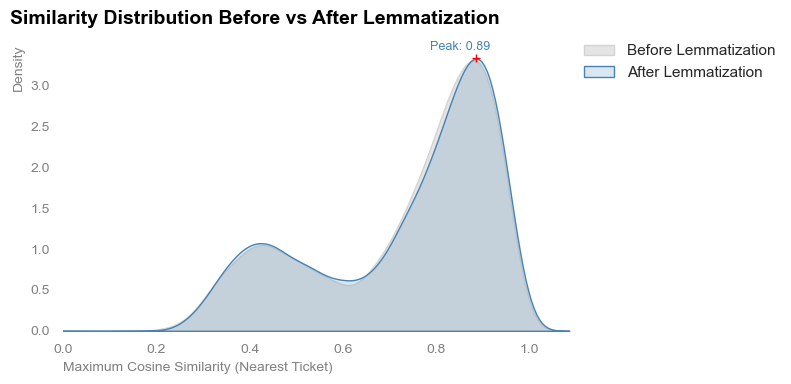

In [10]:
# Lemmatization impact density plot
sns.set_theme(style="white")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(
    raw_sim, label="Before Lemmatization", color="lightgrey", fill=True, alpha=0.6
)
sns.kdeplot(
    lemma_sim, label="After Lemmatization", color="steelblue", fill=True, alpha=0.2
)

# Add a marker at the highest density point of the lemma_sim KDE
kde = gaussian_kde(lemma_sim)
x_vals = np.linspace(lemma_sim.min(), lemma_sim.max(), 1000)
y_vals = kde(x_vals)
peak_x = x_vals[np.argmax(y_vals)]
peak_y = y_vals.max()

ax.annotate(
    f"Peak: {peak_x:.2f}",
    xy=(peak_x, peak_y),
    xytext=(peak_x - 0.1, peak_y + 0.1),
    fontsize=9,
    color="steelblue",
)
ax.plot(peak_x, peak_y, "+", color="red", markersize=6)

# Clean borders: remove top/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Maximum Cosine Similarity (Nearest Ticket)", color="grey")
ax.set_ylabel("Density", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(lemma_sim.min())

# Setting the axis allignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Title parameters
ax.set_title(
    "Similarity Distribution Before vs After Lemmatization",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=15,
    loc="left",
    x=-0.1,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(0.95, 1.05), loc="upper left", edgecolor="white")

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(Config.KDE_PATH, dpi=300, bbox_inches="tight")
print("\nKDE plot of similarity distributions:")
plt.show()

The KDE peak was at 0.89, which is a very high similarity value, indicating that many tickets had very similar text content. This suggests that there are many recurring issues or common themes across the support tickets, which could be valuable for identifying areas for automation or knowledge-base development.

### Quantifying the right-tail

The KS test indicated only a small practical shift in the overall similarity distribution, and the KDE plot showed where that shift is concentrated. To make this effect measurable, we evaluated the proportion of tickets above high-similarity thresholds (0.85, 0.90, 0.95).

We deliberately begin at 0.85 to capture the near-duplicate region relevant for standardisation, automation, and reusable response design. This threshold-based view complements global distribution tests by directly quantifying operationally meaningful recurrence.


Right-tail similarity proportions:


,Threshold,Proportion
0,0.85,0.378
1,0.90,0.206
2,0.95,0.049



Proportion of tickets exceeding high-similarity thresholds:


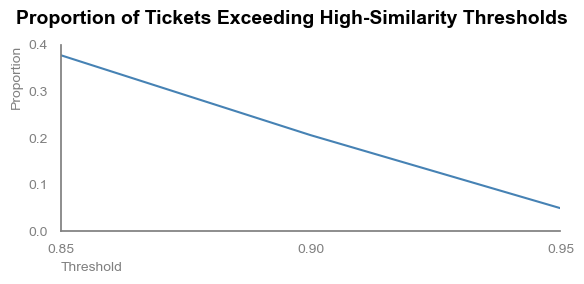

In [11]:
# Quantifying right-tail effect
right_tail_thresholds = [0.85, 0.9, 0.95]
right_tail_stats = []

for threshold in right_tail_thresholds:
    prop = (lemmatised_text_df["Lemma Max Similarity"] >= threshold).mean()
    right_tail_stats.append({"Threshold": threshold, "Proportion": prop})

right_tail_df = pd.DataFrame(right_tail_stats)
print("\nRight-tail similarity proportions:")
display(right_tail_df.style.format({"Threshold": "{:.2f}", "Proportion": "{:.3f}"}))

# Visualise the cumulative tail effect
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 3))

sns.lineplot(data=right_tail_df, x="Threshold", y="Proportion", color="steelblue")

# Set x-axis ticks to the discrete threshold values
ax.set_xticks(right_tail_thresholds)

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(
    right_tail_df["Threshold"].min(),
    right_tail_df["Threshold"].max(),
)

# Set y-axis ticks to fit the proportion values
ax.set_yticks(np.linspace(0, 0.4, 5))

# Clean borders: remove top/right spines
sns.despine(ax=ax)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Threshold", color="grey")
ax.set_ylabel("Proportion", color="grey")
ax.tick_params(colors="grey")

# Set the axis lines to grey for better aesthetics
ax.spines["left"].set_color("grey")
ax.spines["bottom"].set_color("grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# Setting the axis allignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Title parameters
ax.set_title(
    "Proportion of Tickets Exceeding High-Similarity Thresholds",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=15,
    loc="left",
    x=-0.09,
)

plt.tight_layout()
plt.savefig(Config.RIGHT_TAIL_PATH, dpi=300, bbox_inches="tight")

print("\nProportion of tickets exceeding high-similarity thresholds:")
plt.show()

### Category recurrence

We grouped tickets by Type-Queue and calculated the recurrence rate for each: the proportion of tickets with a near-duplicate (≥0.85 similarity). This reveals which categories exhibit the highest thematic concentration and are therefore most actionable for automation or knowledge-base development.

In [12]:
# Creating a combined 'Type - Queue' column for grouping
lemmatised_text_df["Type - Queue"] = (
    lemmatised_text_df["Type"].astype(str)
    + " - "
    + lemmatised_text_df["Queue"].astype(str)
)

threshold = 0.85
records = []

# Loop through categories and compute within-group nearest-neighbour recurrence
for name, group in lemmatised_text_df.groupby("Type - Queue"):
    type_name, queue_name = name.split(" - ", 1)
    tfidf_sub = vec_lemma.transform(group["Lemmatised Text"])
    if tfidf_sub.shape[0] < 2:
        recurrence = 0.0
    else:
        max_similarity_values = max_similarity(tfidf_sub)
        recurrence = float((max_similarity_values >= threshold).mean())

    records.append(
        {
            "Type": type_name,
            "Queue": queue_name,
            "Group Size": len(group),
            "Recurrence Rate": recurrence,
        }
    )

# Create a DataFrame from the records
category_recurrence_df = pd.DataFrame(records)

# Calculate impact score by combining recurrence concentration and queue volume
category_recurrence_df["Impact Score"] = 0.6 * (
    category_recurrence_df["Recurrence Rate"]
    / category_recurrence_df["Recurrence Rate"].max()
) + 0.4 * (
    category_recurrence_df["Group Size"] / category_recurrence_df["Group Size"].max()
)

# Rank by impact score
category_recurrence_df = category_recurrence_df.sort_values(
    "Impact Score", ascending=False
)

category_recurrence_df["Actionable"] = category_recurrence_df["Impact Score"] > 0.5

# Save category recurrence table
category_recurrence_df.to_csv(
    Config.CAT_RECURRENCE_CSV_PATH, index=False, encoding="utf-8"
)

# Show recurrence rates
display(
    category_recurrence_df.style.format(
        {"Recurrence Rate": "{:.3f}", "Group Size": "{:,}", "Impact Score": "{:.3f}"}
    )
)

,Type,Queue,Group Size,Recurrence Rate,Impact Score,Actionable
30,Request,Billing and Payments,657,0.610,0.671,True
19,Incident,Technical Support,"2,053",0.279,0.648,True
0,Change,Billing and Payments,86,0.674,0.617,True
31,Request,Customer Service,926,0.490,0.617,True
39,Request,Technical Support,815,0.501,0.604,True
33,Request,Human Resources,88,0.659,0.604,True
37,Request,Sales and Pre-Sales,209,0.565,0.543,True
35,Request,Product Support,580,0.467,0.529,True
2,Change,General Inquiry,57,0.579,0.526,True
15,Incident,Product Support,"1,181",0.307,0.504,True


### Category recurrence visuals

Finally, we plotted the recurrence rates by Type-Queue to visually identify which categories have the highest concentration of similar tickets. This helps to quickly spot where the most common issues are occurring and where targeted interventions could have the greatest impact.

In [13]:
# Apply Seaborn theme globally
sns.set_theme(style="white")

# Order queues by mean impact score (ascending so highest appears at top)
queue_order = (
    category_recurrence_df.groupby("Queue")["Impact Score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)


Barplot of Impact Score by Queue and Type:


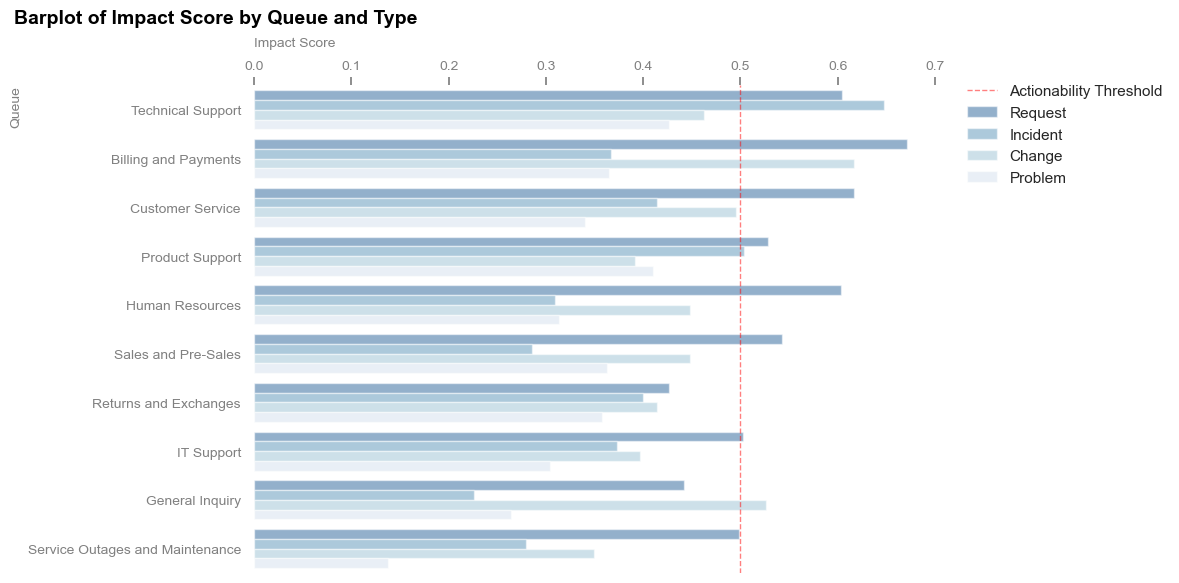

In [14]:
# Horizontal barplot of impact score by queue over type
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(12, 6))

ax.axvline(
    x=0.5,
    color="red",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="Actionability Threshold",
)

# Plot higher-impact points in color by type
sns.barplot(
    data=category_recurrence_df,
    x="Impact Score",
    y="Queue",
    hue="Type",
    palette="Blues_r",
    alpha=0.5,
    order=queue_order,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1.3))
ax.xaxis.labelpad = 10  # Add padding to the x-axis label for better spacing

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title with font size 14 and grey color for subtlety
ax.set_title(
    "Barplot of Impact Score by Queue and Type",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=10,
    loc="left",
    x=-0.35,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.03), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_BARPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nBarplot of Impact Score by Queue and Type:")
plt.show()


Lineplot of Impact Score by Queue and Type:


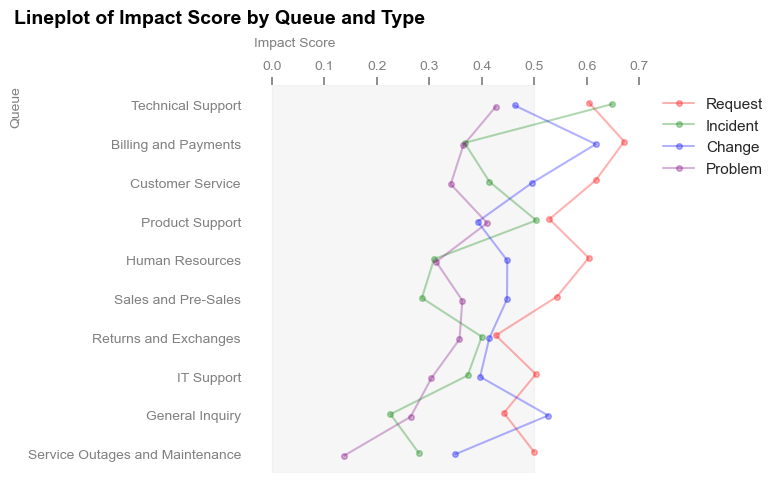

In [15]:
# Visualising the category recurrence rates with a line plot
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 5))

sns.pointplot(
    data=category_recurrence_df,
    y="Queue",
    x="Impact Score",
    hue="Type",
    order=queue_order,
    palette={
        "Request": "red",
        "Incident": "green",
        "Problem": "purple",
        "Change": "blue",
    },
    dodge=True,
    markers="o",
    markersize=4,
    linestyles="-",
    linewidth=1.5,
    alpha=0.3,
)

# Shade the area below impact score of 0.5
ax.axvspan(
    color="lightgrey",
    alpha=0.2,
    zorder=0,
    xmin=0,
    xmax=0.5,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.xaxis.labelpad = 10

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title
ax.set_title(
    "Lineplot of Impact Score by Queue and Type",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=10,
    loc="left",
    x=-0.62,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.005), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_LINEPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nLineplot of Impact Score by Queue and Type:")
plt.show()


Dotplot of Impact Score by Queue and Type:


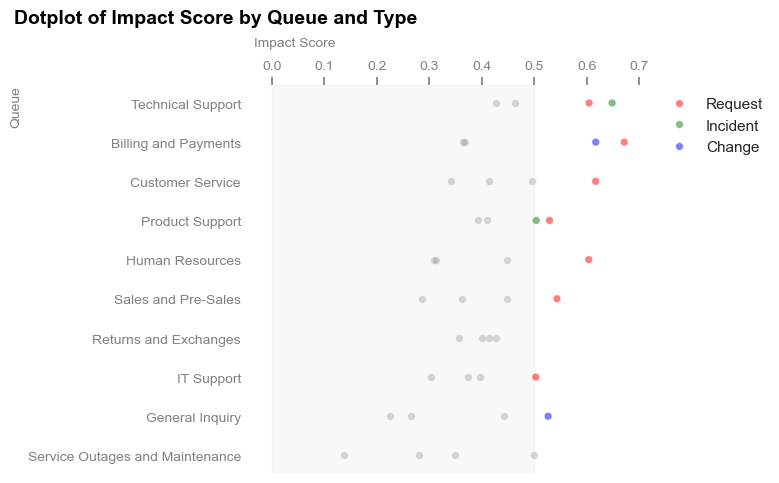

In [16]:
# Dotplot of impact score by queue and type
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 5))

# Anchor all queue positions in the desired order before plotting real data
sns.scatterplot(x=[0.0] * len(queue_order), y=queue_order, alpha=0, s=0)

# Build boolean masks once for readable filtering
actionable_mask = category_recurrence_df["Actionable"].astype(bool)
non_actionable_mask = ~actionable_mask

# Plot lower-impact points in grey
sns.scatterplot(
    data=category_recurrence_df[non_actionable_mask],
    x="Impact Score",
    y="Queue",
    color="grey",
    alpha=0.3,
    s=30,
    legend=False,
)

# Plot higher-impact points in color by type
sns.scatterplot(
    data=category_recurrence_df[actionable_mask],
    x="Impact Score",
    y="Queue",
    hue="Type",
    palette={
        "Change": "blue",
        "Request": "red",
        "Incident": "green",
        "Problem": "purple",
    },
    alpha=0.5,
    s=30,
)

# Shade the area below impact score of 0.5
ax.axvspan(
    color="lightgrey",
    alpha=0.15,
    zorder=0,
    xmin=0,
    xmax=0.5,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.xaxis.labelpad = 10

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title
ax.set_title(
    "Dotplot of Impact Score by Queue and Type",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=10,
    loc="left",
    x=-0.62,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.005), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_DOTPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nDotplot of Impact Score by Queue and Type:")
plt.show()

### Findings

#### Statistical Effect of Lemmatisation

Using the full English subset, lemmatisation produced a 45.08% token reduction while preserving broad corpus geometry.

- KS statistic: 0.0193
- KS p-value: 1.19e-02
- Mean max similarity: 0.733 (before) to 0.733 (after)
- Median max similarity: 0.802 (before) to 0.805 (after)
- Share with max similarity >= 0.85: 36.14% (before) to 37.79% (after)

Interpretation: the shift is statistically detectable but small in magnitude, with a modest concentration increase in the high-similarity tail rather than a broad reshaping of the distribution.

#### Right-Tail Recurrence (Operationally Relevant Thresholds)

The proportion of tickets above strong-similarity thresholds was:

- At >= 0.85: 37.79%
- At >= 0.90: 20.64%
- At >= 0.95: 4.95%

This monotonic decline is expected and indicates that exact or near-exact thematic duplicates are a minority, while broader high-similarity recurrence remains substantial.

#### Category-Level Recurrence and Impact

Recurrence and impact were estimated at the Type-Queue level using within-group nearest-neighbour similarity (threshold = 0.85), then combined with group size into an impact score.

Weighted recurrence by Type (descending):

- Request: 51.54%
- Change: 44.81%
- Problem: 30.36%
- Incident: 30.10%

Highest weighted-recurrence queues included:

- Billing and Payments: 49.52%
- Sales and Pre-Sales: 48.29%
- Human Resources: 43.51%
- Customer Service: 41.32%
- General Inquiry: 40.64%
- Returns and Exchanges: 40.52%

#### Scientific Interpretation

Taken together, these results indicate that lemmatisation increases lexical comparability and strengthens recurrence detection in the right tail without materially distorting global similarity structure. The effect size is moderate and concentrated, which supports its use as a preprocessing step for downstream clustering and prioritisation.

Methodological note: nearest-neighbour cosine similarity is sensitive to corpus composition and vectoriser design; therefore, these estimates should be interpreted as distributional evidence of recurrence rather than direct causal measures of operational burden.